<a href="https://colab.research.google.com/github/Gautam2-468/Student-Performance-Prediction-Using-Linear-Regression/blob/main/Untitled3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

##IMPORTING LIBRABRIES


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import (mean_absolute_error,mean_squared_error)




##Dataset Creation

In [ ]:
np.random.seed(42)

data = {
    "Study_Hours": np.random.randint(1, 11, 100),
    "Attendance": np.random.randint(60, 101, 100),
    "Previous_Score": np.random.randint(40, 96, 100),
    "Assignments_Completed": np.random.randint(1, 11, 100),
    "Sleep_Hours": np.random.randint(4, 9, 100),
}

df = pd.DataFrame(data)

df["Exam_Score"] = (
    2.5 * df["Study_Hours"] +
    0.3 * df["Attendance"] +
    0.4 * df["Previous_Score"] +
    1.5 * df["Assignments_Completed"] +
    1.2 * df["Sleep_Hours"] +
    np.random.randint(-10, 11, 100)
)

df.head()

##Data Exploration


In [ ]:
df.tail()

,Study_Hours,Attendance,Previous_Score,Assignments_Completed,Sleep_Hours,Exam_Score
95,10,97,46,4,5,92.5
96,9,83,42,3,5,75.7
97,7,64,56,7,5,71.6
98,9,93,72,8,6,97.4
99,8,65,87,4,4,93.1


In [ ]:
df.shape

(100, 6)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 6 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Study_Hours            100 non-null    int64  
 1   Attendance             100 non-null    int64  
 2   Previous_Score         100 non-null    int64  
 3   Assignments_Completed  100 non-null    int64  
 4   Sleep_Hours            100 non-null    int64  
 5   Exam_Score             100 non-null    float64
dtypes: float64(1), int64(5)
memory usage: 4.8 KB


In [ ]:
df.describe()

,Study_Hours,Attendance,Previous_Score,Assignments_Completed,Sleep_Hours,Exam_Score
count,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000
mean,5.910000,81.060000,66.480000,5.370000,6.050000,81.620000
std,2.871296,12.761068,15.844879,2.866226,1.452097,12.959346
min,1.000000,60.000000,40.000000,1.000000,4.000000,45.100000
25%,3.000000,70.000000,55.000000,3.000000,5.000000,73.800000
50%,6.000000,83.500000,66.000000,6.000000,6.000000,82.050000
75%,8.000000,92.000000,79.000000,8.000000,7.000000,91.425000
max,10.000000,100.000000,95.000000,10.000000,8.000000,111.300000


##Data Cleaning

In [ ]:
df.isnull().sum()

,0
Study_Hours,0
Attendance,0
Previous_Score,0
Assignments_Completed,0
Sleep_Hours,0
Exam_Score,0


In [ ]:
df.duplicated().sum()

np.int64(0)

##Correlation Analysis

In [ ]:
df.corr(numeric_only=True)

,Study_Hours,Attendance,Previous_Score,Assignments_Completed,Sleep_Hours,Exam_Score
Study_Hours,1.000000,-0.116738,0.112859,0.010224,0.144027,0.620332
Attendance,-0.116738,1.000000,-0.151711,-0.027125,-0.025784,0.235967
Previous_Score,0.112859,-0.151711,1.000000,-0.082240,0.097286,0.474172
Assignments_Completed,0.010224,-0.027125,-0.082240,1.000000,-0.091860,0.269508
Sleep_Hours,0.144027,-0.025784,0.097286,-0.091860,1.000000,0.247825
Exam_Score,0.620332,0.235967,0.474172,0.269508,0.247825,1.000000


In [ ]:
df.corr(numeric_only=True)["Exam_Score"].sort_values(ascending=False)

,Exam_Score
Exam_Score,1.000000
Study_Hours,0.620332
Previous_Score,0.474172
Assignments_Completed,0.269508
Sleep_Hours,0.247825
Attendance,0.235967


## Data Visualization

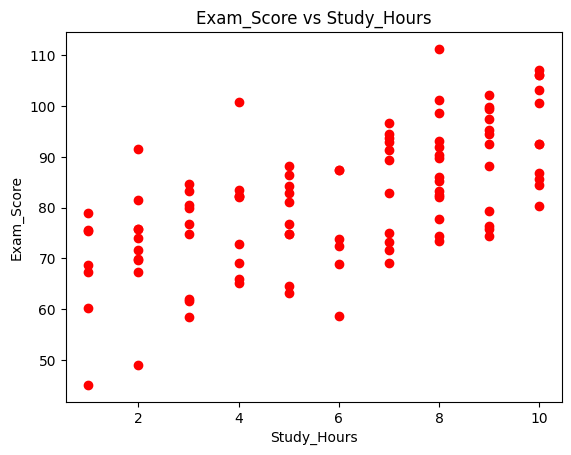

In [ ]:
plt.scatter(df['Study_Hours'],df["Exam_Score"],color = 'red')
plt.xlabel("Study_Hours")
plt.ylabel("Exam_Score")
plt.title("Exam_Score vs Study_Hours")
plt.show()

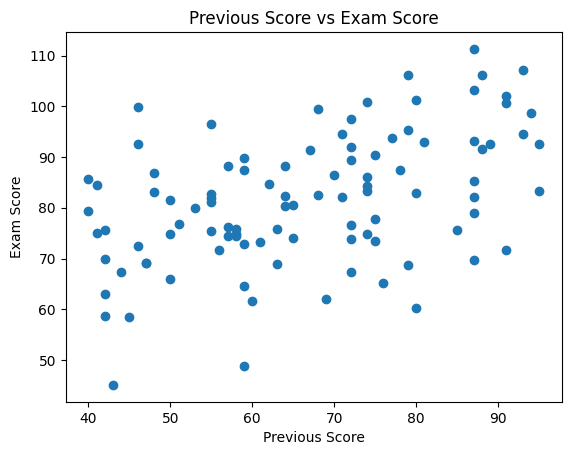

In [ ]:
plt.scatter(df["Previous_Score"], df["Exam_Score"])
plt.title("Previous Score vs Exam Score")
plt.xlabel("Previous Score")
plt.ylabel("Exam Score")
plt.show()

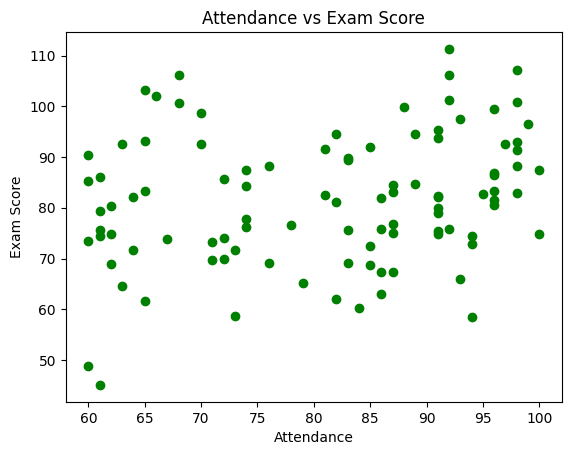

In [ ]:
plt.scatter(df["Attendance"], df["Exam_Score"],color = "green")
plt.title("Attendance vs Exam Score")
plt.xlabel("Attendance")
plt.ylabel("Exam Score")
plt.show()

## Train-Test Split

In [ ]:
x = df[["Study_Hours","Attendance","Previous_Score","Assignments_Completed","Sleep_Hours"]]

y = df["Exam_Score"]

In [ ]:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)
print(x_train.shape)
print(x_test.shape)

(80, 5)
(20, 5)


## Model Training

In [ ]:
model = LinearRegression()
model.fit(x_train,y_train)

LinearRegression()

##Prediction

In [ ]:
prediction = model.predict([[8,90,80,9,7]])

print(prediction)

[103.01376225]


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


##Feature Importance


In [ ]:
feature_importance = pd.DataFrame({
    "Feature": x.columns,
    "Coefficient": model.coef_
})
feature_importance.sort_values(
    by="Coefficient",
    ascending=False
)

,Feature,Coefficient
0,Study_Hours,2.640899
4,Sleep_Hours,1.712226
3,Assignments_Completed,1.461500
1,Attendance,0.415255
2,Previous_Score,0.386655


##Model Evaluation

In [ ]:
print(model.score(x_test, y_test))

0.7519927155746049


In [ ]:
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)

print(mae)
print(mse)

5.397108565024646
36.21789258543325


##Actual vs Predicted Plot

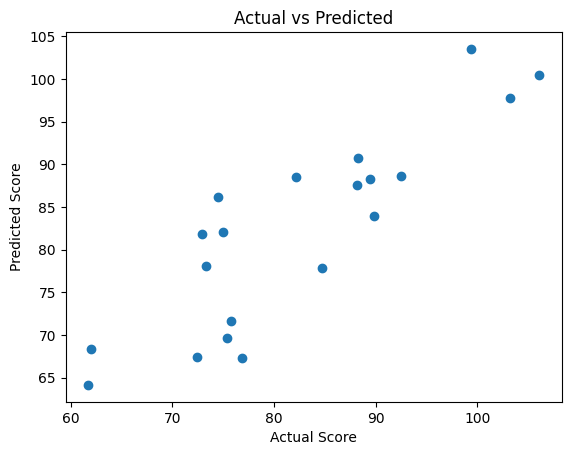

In [ ]:
y_pred = model.predict(x_test)

plt.scatter(y_test, y_pred)
plt.xlabel("Actual Score")
plt.ylabel("Predicted Score")
plt.title("Actual vs Predicted")
plt.show()